# Day 12 — 311 Response Time: Does the City Respond Faster in Wealthier Zip Codes?

---

## The question

You've already cleaned 311 data (Days 2–3) and mapped complaint rates by zip code (Days 5–6). Today you go one level deeper: not just *how many* complaints, but *how fast did the city respond* to them?

If response time is faster in wealthier zip codes, that's evidence of unequal service delivery — the city spending the same tax dollars faster in areas that already have more resources. If there's no relationship, that tells a different story.

This is the kind of analysis that shows up in journalism (ProPublica, The City), in housing advocacy, and in city audits.

## New concept: timedelta arithmetic

311 records have two date columns: `Created Date` (when the complaint was filed) and `Closed Date` (when the city marked it resolved). Response time = Closed Date − Created Date.

In pandas, subtracting two datetime columns gives a **timedelta** — a duration. Think of it like subtracting two times on a clock: 3:45 PM − 1:00 PM = 2 hours 45 minutes. Pandas gives you the result in days.

```python
df['response_days'] = (df['Closed Date'] - df['Created Date']).dt.days
```

`.dt.days` extracts just the number of days as an integer. Without it you get a raw timedelta object that's harder to work with.

## Organization rules
- One task per cell.
- Sanity check after every major step.
- Negative response times mean bad data — handle them explicitly.

In [184]:
# CELL 1 — Imports only.
import pandas as pd
import matplotlib.pyplot as plt

In [185]:
# CELL 2 — Load 311 data.
# Load your 311 CSV (the same file from Days 2-3) into df_311.
# You'll need: 'Created Date', 'Closed Date', 'Incident Zip', 'Complaint Type', 'Borough'
# Use usecols= to load only those columns — the full 311 file is large.
#
# Sanity check: print shape and df_311.head(3)
#
# TODO: write the pd.read_csv() call with usecols

df_311 = pd.read_csv("../data/311_cleaned.csv", usecols=['Created Date', 'Closed Date', 'Incident Zip', 'Problem (formerly Complaint Type)', 'Borough'])

print(df_311.shape)


(106402, 5)


In [186]:
# CELL 3 — Filter to Brooklyn.
# Filter df_311 to rows where Borough == 'BROOKLYN'.
# Store as df_brooklyn.
# Sanity check: print len(df_brooklyn)
#
# TODO

df_brooklyn = df_311[df_311['Borough'] == 'BROOKLYN']

print(len(df_brooklyn))


106402


In [187]:
# CELL 4 — Parse dates.
# Convert 'Created Date' and 'Closed Date' to datetime.
# Use pd.to_datetime() on each column.
# Sanity check: print df_brooklyn[['Created Date', 'Closed Date']].dtypes
# Both should show datetime64.
#
# TODO


df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])

df_brooklyn['Closed Date'] = pd.to_datetime(df_brooklyn['Closed Date'])

print(df_brooklyn[['Created Date', 'Closed Date']].dtypes)




/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_79851/4153543563.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])


Created Date    datetime64[us]
Closed Date     datetime64[us]
dtype: object


In [188]:
# CELL 5 — Calculate response time.
# New column: response_days = (Closed Date - Created Date).dt.days
# Then filter out rows where response_days is negative or null.
# Negative means the closed date is before the created date — bad data.
# Store the clean result as df_brooklyn (overwrite is fine here).
#
# Sanity check: print df_brooklyn['response_days'].describe()
# Min should be 0, mean should be somewhere between 1-30 days.
#
# TODO

df_brooklyn['Response Days'] = (df_brooklyn['Closed Date'] - df_brooklyn['Created Date']).dt.days

df_brooklyn = df_brooklyn[(df_brooklyn['Response Days'] >= 0) & (df_brooklyn['Response Days'].notna())]

print(df_brooklyn['Response Days'].describe())



count    94487.000000
mean         1.705515
std          4.096900
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         34.000000
Name: Response Days, dtype: float64


**Before moving on — answer these:**
- What is the median response time in days? Does that seem reasonable?
- What percentage of rows had negative response times and got dropped? What might cause a negative response time in real data?
- What does a response time of 0 days mean — instant resolution, or something else?

the median response times seems to be roughly 2 days which is reasonable i think for a situation to be resolved

about 5000 rows got deleted as 0 or null values i think maybe a clerical error or the claim being closed but then someone entering data forgot the opening date for the issue

i'd say instant resolution or the claim was probably not deemed sufficient enough for 311 to respond to

In [189]:
# CELL 6 — Median response time by zip code.
# Group df_brooklyn by 'Incident Zip'.
# Calculate median response_days and count of complaints per zip.
# Store as df_by_zip.
# Only keep zips with at least 50 complaints (small samples give unreliable medians).
# Sort by median response time descending.
# Print the top 10 slowest zip codes.
#
# TODO

# Returns the total row count for each unique zip code
df_by_zip = df_brooklyn.groupby('Incident Zip').agg(
    median_response=('Response Days', 'median'),
    num_complaints=('Response Days', 'count')
)

# Keep only zips with enough data to be reliable
df_by_zip = df_by_zip[df_by_zip['num_complaints'] >= 50]

df_by_zip = df_by_zip.sort_values('median_response', ascending=False)
#print(df_by_zip.head(50))

housing_types = ['HEAT/HOT WATER', 'PLUMBING', 'PAINT/PLASTER', 
                 'DOOR/WINDOW', 'UNSANITARY CONDITION', 'ELEVATOR']

df_housing = df_brooklyn[df_brooklyn['Problem (formerly Complaint Type)'].isin(housing_types)]
print(len(df_housing))
print(df_housing['Response Days'].describe())

print(df_housing['Response Days'].value_counts().head(10))








9292
count    9292.000000
mean        5.573612
std         6.257323
min         0.000000
25%         1.000000
50%         3.000000
75%         8.000000
max        34.000000
Name: Response Days, dtype: float64
Response Days
1.0    1694
0.0    1294
2.0    1057
3.0     688
4.0     641
5.0     591
6.0     548
7.0     432
8.0     368
9.0     245
Name: count, dtype: int64


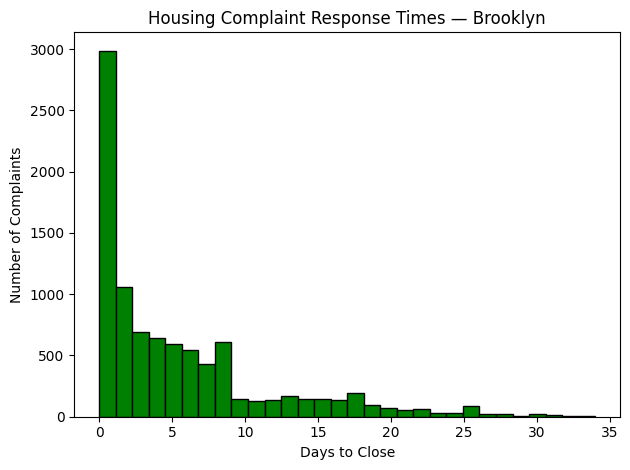

In [190]:
# CELL 7 — Plot: distribution of response times.
# Plot a histogram of response_days.
# Cap at 60 days so outliers don't squash the chart.
# Add title and axis labels.
#
# TODO



df_housing['Response Days'].clip(upper=60).plot.hist(
    bins=30,
    edgecolor='black',
    color='green'
)
plt.title('Housing Complaint Response Times — Brooklyn')
plt.xlabel('Days to Close')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()



count    67.000000
mean      2.126866
std       2.734936
min       0.000000
25%       0.000000
50%       1.000000
75%       3.500000
max      10.000000
Name: median_response, dtype: float64


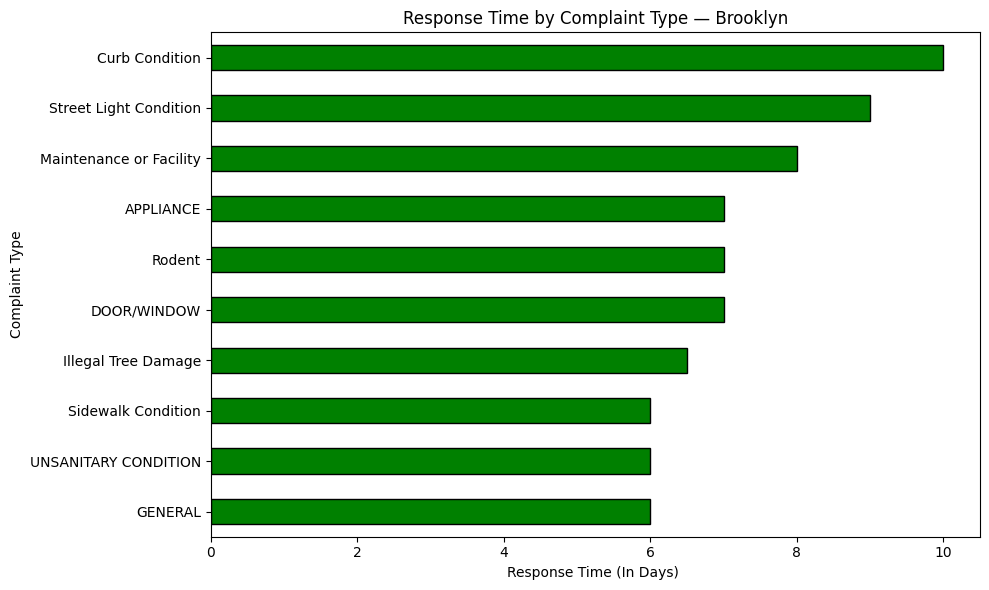

In [191]:
# CELL 8 — Response time by complaint type.
# Group by 'Complaint Type', get median response_days.
# Filter to types with at least 100 complaints.
# Plot horizontal bar chart of the top 10 slowest complaint types.
#
# Which complaint types take longest? Which are fastest?
# Think about whether faster = better (a closed noise complaint
# might just mean the city stopped tracking it, not that it was resolved).
#
# TODO

df_by_complaint_type = df_brooklyn.groupby('Problem (formerly Complaint Type)').agg(
    median_response=('Response Days', 'median'),
    num_complaints=('Response Days', 'count')
  
)

df_by_complaint_type = df_by_complaint_type[df_by_complaint_type['num_complaints'] >= 100]


print(df_by_complaint_type['median_response'].describe())




df_by_complaint_type.sort_values('median_response', ascending=False).head(10)['median_response'].plot.barh(
   



edgecolor='black',
color='green',
figsize=(10, 6)
)
plt.title('Response Time by Complaint Type — Brooklyn')
plt.xlabel('Response Time (In Days) ')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()












**Critical thinking pause:**
- Which complaint types are slowest? Are those the ones you expected?
- A 'Closed Date' just means the agency closed the ticket — not that the problem was fixed. What does that mean for interpreting response time as a measure of service quality?
- If you were a housing advocate in Bushwick, which complaint type's response time would you focus on? Why?

Curb condition and street light condition are the ones that take the longest to be responded to, and these are the commons and I think because these are city aesthetics they take longer than domestic issues to be resolved because of the priority

The problem could still be persisting but they just added a bandage to it and aren't actually gonna repair it fully. This could mean a wide variablility for service quality, depending on the issue. 

Honestly and it sounds boring but but street and light conditions, these things cause a decline in the aesthetics and safety of a neighborhood and further drive people away from areas, the fact that these take the longest shows what can be priroritized yes the faster response times deserved to be addressed ASAP but I feel things that affect street conditino should too

In [192]:
# CELL 9 — Focus on Bushwick zip codes.
# Filter df_brooklyn to zip codes 11221 and 11237.
# Store as df_bushwick_311.
# Print: total complaints, median response time, and the
# top 5 complaint types by count.
#
# TODO




# Step 2: Filter WITHIN that result for your 2 specific ZIP codes
# Pass your two ZIP codes as integers or strings depending on your data type
df_bushwick_311 = df_brooklyn[df_brooklyn['Incident Zip'].isin([11221.0, 11237.0])]




print(df_bushwick_311.describe())
print(df_bushwick_311['Response Days'].median())








                     Created Date                 Closed Date  Incident Zip  \
count                        5495                        5495   5495.000000   
mean   2026-05-16 18:54:00.523202  2026-05-18 17:24:49.097361  11227.702821   
min           2026-05-01 00:00:55         2026-05-01 00:49:19  11221.000000   
25%           2026-05-08 22:17:44  2026-05-11 00:35:32.500000  11221.000000   
50%           2026-05-17 00:05:49         2026-05-18 22:48:41  11221.000000   
75%           2026-05-24 10:02:02         2026-05-26 22:09:10  11237.000000   
max           2026-05-31 23:43:06         2026-06-06 22:43:57  11237.000000   
std                           NaN                         NaN      7.894851   

       Response Days  
count    5495.000000  
mean        1.708098  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         2.000000  
max        34.000000  
std         3.787392  
0.0


In [ ]:
# CELL 10 — Compare Bushwick response time to Brooklyn median.
# Calculate:
#   brooklyn_median = df_brooklyn['response_days'].median()
#   bushwick_median = df_bushwick_311['response_days'].median()
# Print both and the difference.
# Is Bushwick faster or slower than the Brooklyn average?
#
# TODO

brooklyn_median = df_brooklyn[df_brooklyn['Response Days'] > 0]['Response Days'].median()
bushwick_median = df_bushwick_311[df_bushwick_311['Response Days'] > 0]['Response Days'].median()

print(brooklyn_median)
print(bushwick_median)


4.0
3.0


**Critical thinking pause:**
- Is Bushwick faster or slower than the Brooklyn median? By how many days?
- What would you need to know to say whether that difference is meaningful vs. random noise?
- If Bushwick is slower: what would you do with this finding as a community organizer? As a city council member? As a journalist?

Bushwick is actually faster to get issues resolved in brooklyn than the borough average by a day

I'd need to know what type of incidents tend to be resolved in that time frame and id be curious to see this by category

I argue that bushwick could be even faster it's the relatively up and coming neighborhood and more invewstment in the condition of the neighborhood is needed and would really help the optics of the city and imporve the QOL of the people living here

*(Write your answers here)*

## Day 12 Recap

| What you did | Why it matters |
|---|---|
| Timedelta arithmetic | Turned two dates into a usable duration |
| Filtered negative response times | Real data has impossible values — always check |
| Median by zip / complaint type | Showed where service is slowest |
| Bushwick vs Brooklyn comparison | Grounded the citywide pattern in your neighborhood |

### What's coming on Day 13
Combining all your datasets — 311 response time, ACRIS sale prices, PLUTO building data — into a single displacement risk score per zip code. The first time everything you've built connects into one analysis.